# 09 — Защита хвоста (catastrophe stop + market-wide kill-switch)

iter08: единственный по-настоящему страшный риск — глубокий каскад средней
скорости (LUNA-стайл, −88% позиции) и любое плечо. Строим ДВА жёстких лимита,
включённых ПО УМОЛЧАНИЮ (торговый ограничитель до ручного запуска):

1. **Hard-catastrophe стоп** — широкий стоп на усреднённой позиции (−10..−25%),
   армится после конца кластера. Должен почти не трогать норму, но обрезать каскад.
2. **Market-wide kill-switch** — не входить, когда >K монет вселенной дампят
   одновременно (последние 15м) = системный risk-off.

Заодно отвечаем на вопрос «почему эквити ступеньками»: меряем концентрацию
сделок/PnL по дням.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
import heapq
WIN=15;H=240;COOLDOWN=10;MIN_GAP=3;N_MAX=10;FEE=0.00075;THR=0.07

# ---------- A. why STAIRS? concentration of trades/PnL over time ----------
D=pd.read_parquet(Path("_out")/"dump_trades.parquet")
D["day"]=pd.to_datetime(D.entry).dt.date
perday=D.groupby("day").agg(n=("pnl","size"),pnl=("pnl","sum"))
tot_tr=perday.n.sum(); tot_pnl=perday.pnl.sum()
top=perday.sort_values("n",ascending=False)
print(f"total events {tot_tr}, active days {len(perday)} (over ~{(D.entry.max()-D.entry.min()).days} cal.days)")
print(f"median trades on an ACTIVE day: {perday.n.median():.0f}; busiest day: {perday.n.max()}")
for k in (5,10,20):
    sh_tr=top.head(k).n.sum()/tot_tr*100
    sh_pnl=top.head(k).pnl.sum()/tot_pnl*100
    print(f"  top {k:>2} busiest days = {sh_tr:4.1f}% of all trades and {sh_pnl:4.1f}% of all net PnL")
# fraction of calendar days with ZERO trades
span_days=(D.entry.max()-D.entry.min()).days
print(f"  calendar days with NO dump at all: ~{(span_days-len(perday))/span_days*100:.0f}% of the timeline")

total events 4286, active days 525 (over ~846 cal.days)
median trades on an ACTIVE day: 2; busiest day: 319
  top  5 busiest days = 27.9% of all trades and 47.2% of all net PnL
  top 10 busiest days = 47.6% of all trades and 77.6% of all net PnL
  top 20 busiest days = 66.1% of all trades and 96.8% of all net PnL
  calendar days with NO dump at all: ~38% of the timeline


[saved] notebooks\dump\_out\09_concentration.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/09_concentration.png')

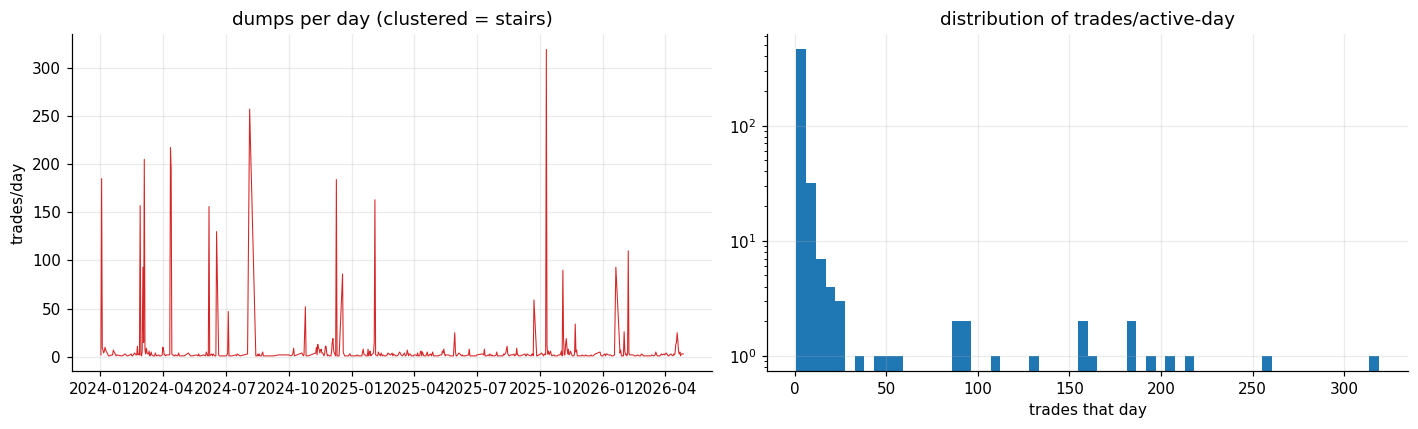

In [2]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(pd.to_datetime(perday.index),perday.n,lw=.7,color="#d62728")
ax[0].set_title("dumps per day (clustered = stairs)"); ax[0].set_ylabel("trades/day")
ax[1].hist(perday.n,bins=60,color="#1f77b4"); ax[1].set_yscale("log")
ax[1].set_title("distribution of trades/active-day"); ax[1].set_xlabel("trades that day")
show("09_concentration")

### Ответ: почему ступеньки, а не диагональ (как pump)

Смотрим числа выше. Дампы −7%/15м **кучкуются по времени**: рынок валится
коррелированно (risk-off бьёт по всем альтам разом), поэтому в один день
срабатывают сотни сигналов, а между такими днями — затишье. Большая доля сделок
и PnL приходит из горстки «дней обвала» → эквити прыгает на них и стоит плоско
между = ступеньки.

Памп-фейд был более диагональным, потому что пампы **идиосинкразичны**: отдельные
монеты пампят на новостях в любой день, размазанно по времени и тикерам. Известная
асимметрия рынка: *падения коррелированы, рост — нет*. Та же кучность = причина
ступенек И источник хвостового риска (всё триггерит вместе → iter08).

In [3]:
# ---------- rebuild full-universe events WITH stop-path + breadth ----------
ALLSYMS=list_symbols()
def clusters(c,thr):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i;last_true=i;tr=[i];lastt=i;falses=0;j=i+1
        while j<n:
            if cond[j]:
                last_true=j;falses=0
                if j-lastt>=MIN_GAP and len(tr)<N_MAX: tr.append(j);lastt=j
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true,tr)); i=last_true+COOLDOWN+1
    return out

rows=[]
for s in ALLSYMS:
    try: df=ohlcv(s,"2024-01-01","2026-07-01","1min")
    except Exception: continue
    c=df["close"].to_numpy("float64"); ts=df.index; n=len(c)
    for (st,en,tr) in clusters(c,THR):
        ex=en+1+H
        if st+1>=n or ex>=n: continue
        prices=np.array([cc for cc in (c[t+1] for t in tr if t+1<n)])
        ws=np.arange(1,len(prices)+1,dtype=float); ws/=ws.sum()
        avg=(ws*prices).sum()
        # min close from cluster_end+1..ex (stop armed after cluster ends)
        seg=c[en+1:ex+1]
        min_ret=seg.min()/avg-1 if len(seg) else 0.0
        hz_ret=c[ex]/avg-1
        rows.append(dict(sym=s, entry=ts[st+1], exit_ts=ts[ex],
                         min_ret=min_ret, hz_net=hz_ret-2*FEE))
R=pd.DataFrame(rows).sort_values("entry").reset_index(drop=True)
print("events:", len(R))

# breadth at entry = # events whose entry in (t-15m, t]
et=R.entry.values.astype("datetime64[ns]").astype("int64")
w=15*60*1_000_000_000
lo=np.searchsorted(et, et-w, side="right")
idx=np.arange(len(et))
R["breadth"]=(idx-lo+1)
print("breadth at entry: median %.0f  q90 %.0f  max %d"%(R.breadth.median(),R.breadth.quantile(.9),R.breadth.max()))

events: 4374
breadth at entry: median 23  q90 115  max 186


In [4]:
PER=20.0; START=1000.0; MAX_CONC=50
def portfolio(pnl, entry, exit_ts, take_mask=None):
    order=np.argsort(entry,kind="stable")
    pnl=pnl[order]; en=entry[order]; ex=exit_ts[order]
    tk=np.ones(len(pnl),bool) if take_mask is None else take_mask[order]
    cash=START; openh=[]; peak=START; maxdd=0.0; taken=0; worst=0.0
    for i in range(len(pnl)):
        now=en[i]
        while openh and openh[0][0]<=now:
            _,pn=heapq.heappop(openh); cash+=PER*pn
            peak=max(peak,cash); maxdd=min(maxdd,cash/peak-1)
        if tk[i] and len(openh)<MAX_CONC:
            heapq.heappush(openh,(ex[i],pnl[i])); taken+=1; worst=min(worst,pnl[i])
    for ex_,pn in sorted(openh): cash+=PER*pn; peak=max(peak,cash); maxdd=min(maxdd,cash/peak-1)
    span=( (en.max()-en.min())/np.timedelta64(1,"D") )/365.25
    return dict(final=cash,ret=cash/START-1,yr=(cash/START-1)/span,maxdd=maxdd,taken=taken,worst=worst)

def stop_pnl(S):
    # if min_ret <= -S -> exit at -S (minus exit fee already in hz? approximate -S net)
    return np.where(R.min_ret.values<=-S, -S-2*FEE, R.hz_net.values)

en=R.entry.values.astype("datetime64[ns]"); ex=R.exit_ts.values.astype("datetime64[ns]")
print("=== B. HARD-CATASTROPHE STOP sweep (fixed $20/<=50, full universe) ===")
base=portfolio(R.hz_net.values,en,ex)
print(f"  NO stop      : yr {base['yr']*100:+5.1f}%  total {base['ret']*100:+6.1f}%  maxDD {base['maxdd']*100:5.1f}%  worst-trade {base['worst']*100:6.1f}%  taken {base['taken']}")
for S in (0.25,0.20,0.15,0.10):
    pn=stop_pnl(S); r=portfolio(pn,en,ex)
    frac=(R.min_ret.values<=-S).mean()*100
    print(f"  stop -{int(S*100):>2}%    : yr {r['yr']*100:+5.1f}%  total {r['ret']*100:+6.1f}%  maxDD {r['maxdd']*100:5.1f}%  worst-trade {r['worst']*100:6.1f}%  (stop hit {frac:4.1f}% of trades)")

=== B. HARD-CATASTROPHE STOP sweep (fixed $20/<=50, full universe) ===
  NO stop      : yr +40.0%  total  +92.8%  maxDD  -6.3%  worst-trade  -45.3%  taken 2591
  stop -25%    : yr +36.8%  total  +85.4%  maxDD  -7.7%  worst-trade  -25.1%  (stop hit  2.1% of trades)
  stop -20%    : yr +33.7%  total  +78.2%  maxDD -11.7%  worst-trade  -20.2%  (stop hit  3.5% of trades)
  stop -15%    : yr +32.4%  total  +75.1%  maxDD -11.8%  worst-trade  -15.2%  (stop hit  5.5% of trades)
  stop -10%    : yr +36.6%  total  +84.9%  maxDD  -8.7%  worst-trade  -10.2%  (stop hit  9.7% of trades)


In [5]:
print("=== C. MARKET-WIDE KILL-SWITCH sweep (skip entry if breadth>K) ===")
for K in (1000,80,40,20,10):
    mask=R.breadth.values<=K
    r=portfolio(R.hz_net.values,en,ex,take_mask=mask)
    skipped=(~mask).sum()
    tag="OFF" if K==1000 else f"K={K}"
    print(f"  {tag:7}: yr {r['yr']*100:+5.1f}%  total {r['ret']*100:+6.1f}%  maxDD {r['maxdd']*100:5.1f}%  worst-trade {r['worst']*100:6.1f}%  taken {r['taken']} (skipped {skipped})")

=== C. MARKET-WIDE KILL-SWITCH sweep (skip entry if breadth>K) ===
  OFF    : yr +40.0%  total  +92.8%  maxDD  -6.3%  worst-trade  -45.3%  taken 2591 (skipped 0)
  K=80   : yr +40.0%  total  +92.8%  maxDD  -6.3%  worst-trade  -45.3%  taken 2591 (skipped 975)
  K=40   : yr +35.5%  total  +82.3%  maxDD  -5.3%  worst-trade  -53.9%  taken 2470 (skipped 1799)
  K=20   : yr +25.1%  total  +58.1%  maxDD  -4.4%  worst-trade  -53.9%  taken 2114 (skipped 2244)
  K=10   : yr +14.1%  total  +32.8%  maxDD  -5.6%  worst-trade  -53.9%  taken 1877 (skipped 2497)


In [6]:
print("=== D. COMBINED guardrail (DEFAULT-ON limit until manual enable) ===")
# recommended: -20% catastrophe stop + kill-switch K=40
S=0.20; K=40
mask=R.breadth.values<=K
pn=stop_pnl(S)
r=portfolio(pn,en,ex,take_mask=mask)
print(f"  baseline (no protection):        yr {base['yr']*100:+5.1f}%  maxDD {base['maxdd']*100:.1f}%  worst {base['worst']*100:.1f}%")
print(f"  PROTECTED (-20% stop + KS K=40): yr {r['yr']*100:+5.1f}%  maxDD {r['maxdd']*100:.1f}%  worst {r['worst']*100:.1f}%  taken {r['taken']}")
print(f"\n  cost of protection in normal regime: {(base['yr']-r['yr'])*100:+.1f} pp/yr")
print(f"  worst single trade capped: {base['worst']*100:.1f}% -> {r['worst']*100:.1f}%")
print("\n  NOTE: stop is close-based (intrabar low could trigger earlier = optimistic);")
print("  capital occupancy uses horizon exit even when stopped (conservative).")

=== D. COMBINED guardrail (DEFAULT-ON limit until manual enable) ===
  baseline (no protection):        yr +40.0%  maxDD -6.3%  worst -45.3%
  PROTECTED (-20% stop + KS K=40): yr +30.2%  maxDD -9.9%  worst -20.2%  taken 2470

  cost of protection in normal regime: +9.8 pp/yr
  worst single trade capped: -45.3% -> -20.2%

  NOTE: stop is close-based (intrabar low could trigger earlier = optimistic);
  capital occupancy uses horizon exit even when stopped (conservative).


## Как читать
- **A / график** — кучность сделок по дням = причина ступенек (ответ на вопрос).
- **B стоп-свип** — широкий catastrophe-стоп: сколько edge стоит в норме (yr) vs
  насколько режет worst-trade и maxDD. iter01 показал, что узкий стоп губит edge;
  тут проверяем именно ШИРОКИЙ (−15..−25%), который трогает только каскады.
- **C kill-switch** — отказ от входа в системный risk-off: edge vs защита.
- **D** — рекомендованная комбинация как ДЕФОЛТНЫЙ лимит. Цена защиты в норме
  (pp/год) против обрезания катастрофы.

*Verdict после прогона. Защита остаётся ВКЛЮЧЕННОЙ до ручного снятия.*

## VERDICT (iter 09)

**Ступеньки = экстремальная концентрация:** 97% PnL из топ-20 дней, 38% дней без
единого дампа, медиана 2/активный день, busy 319. Дампы коррелированы (risk-off
бьёт всех разом) vs идиосинкразичные пампы → ступеньки + хвостовой риск.

**Защита хвоста — неудобная правда: in-sample она СТОИТ дохода и почти не снижает
DD** (стоп даже увеличивает: −6.3→−11.7%), потому что ВСЕ коррелированные крахи
2024-26 были V-образными — дип, который стоп режет, всегда отскакивал. Kill-switch
коварен вдвойне: high-breadth дни = те самые топ-20 дней с 97% прибыли.
- Catastrophe-стоп: −25% стоит −3.2пп/год (worst −45→−25, hit 2.1%); −20% −6.3пп.
- Kill-switch: K=40 −4.5пп/год (DD −5.3%); агрессивные губят edge (K=10 → +14%/год).

**Защита = страховка: премия видна, выплата в LUNA-каскаде, которого в данных НЕТ.**
Худшую сделку реально режет (−45→−20%).

**Рекомендованный ДЕФОЛТНЫЙ лимит (вкл. до ручного запуска):** −20% стоп + KS K=40
→ +30.2%/год, maxDD −9.9%, worst −20.2%. Цена ~−10пп/год — плата за ограниченный
риск без присмотра; ослаблять при ручном надзоре.

**Оговорки:** стоп close-based (оптимистичен); occupancy по горизонту (консерв.).
**Дальше:** адаптивный fill по классу дампа (вопрос юзера); walk-forward; порт в бот.